In [1]:
import numpy as np
import pandas as pd

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [3]:
test_data = pd.read_csv("pulsar_data_test.csv")
train_data = pd.read_csv("pulsar_data_train.csv")

In [4]:
df = pd.concat([test_data,train_data], ignore_index=True)

In [5]:
df.head()

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
0,116.906250,48.920605,0.186046,-0.129815,3.037625,17.737102,8.122621,78.813405,NaN
1,75.585938,34.386254,2.025498,8.652913,3.765050,21.897049,7.048189,55.878791,NaN
2,103.273438,46.996628,0.504295,0.821088,2.244983,15.622566,9.330498,105.134941,NaN
3,101.078125,48.587487,1.011427,1.151870,81.887960,81.464136,0.485105,-1.117904,NaN
4,113.226562,48.608804,0.291538,0.292120,6.291806,26.585056,4.540138,21.708268,NaN


In [6]:
train_data.head()

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
0,121.156250,48.372971,0.375485,-0.013165,3.168896,18.399367,7.449874,65.159298,0.0
1,76.968750,36.175557,0.712898,3.388719,2.399666,17.570997,9.414652,102.722975,0.0
2,130.585938,53.229534,0.133408,-0.297242,2.743311,22.362553,8.508364,74.031324,0.0
3,156.398438,48.865942,-0.215989,-0.171294,17.471572,NaN,2.958066,7.197842,0.0
4,84.804688,36.117659,0.825013,3.274125,2.790134,20.618009,8.405008,76.291128,0.0


Exploratory Data Analysis (EDA)

In [7]:
df.shape

(17898, 9)

In [8]:
train_data.shape

(12528, 9)

In [9]:
df.columns

Index([' Mean of the integrated profile',
       ' Standard deviation of the integrated profile',
       ' Excess kurtosis of the integrated profile',
       ' Skewness of the integrated profile', ' Mean of the DM-SNR curve',
       ' Standard deviation of the DM-SNR curve',
       ' Excess kurtosis of the DM-SNR curve', ' Skewness of the DM-SNR curve',
       'target_class'],
      dtype='str')

In [10]:
df.columns = df.columns.str.strip()
df.columns

Index(['Mean of the integrated profile',
       'Standard deviation of the integrated profile',
       'Excess kurtosis of the integrated profile',
       'Skewness of the integrated profile', 'Mean of the DM-SNR curve',
       'Standard deviation of the DM-SNR curve',
       'Excess kurtosis of the DM-SNR curve', 'Skewness of the DM-SNR curve',
       'target_class'],
      dtype='str')

In [11]:
# rename column names

df.columns = ['Mean','SD','Kurtosis','Skewness','DM_SNR_Mean','DM_SMR_SD','DM-SNR Kurtosis','DM-SNR Skewness','Target_class']

In [12]:
df.columns

Index(['Mean', 'SD', 'Kurtosis', 'Skewness', 'DM_SNR_Mean', 'DM_SMR_SD',
       'DM-SNR Kurtosis', 'DM-SNR Skewness', 'Target_class'],
      dtype='str')

In [13]:
df.head()

,Mean,SD,Kurtosis,Skewness,DM_SNR_Mean,DM_SMR_SD,DM-SNR Kurtosis,DM-SNR Skewness,Target_class
0,116.906250,48.920605,0.186046,-0.129815,3.037625,17.737102,8.122621,78.813405,NaN
1,75.585938,34.386254,2.025498,8.652913,3.765050,21.897049,7.048189,55.878791,NaN
2,103.273438,46.996628,0.504295,0.821088,2.244983,15.622566,9.330498,105.134941,NaN
3,101.078125,48.587487,1.011427,1.151870,81.887960,81.464136,0.485105,-1.117904,NaN
4,113.226562,48.608804,0.291538,0.292120,6.291806,26.585056,4.540138,21.708268,NaN


In [14]:
df['Target_class'].value_counts()

Target_class
0.0    11375
1.0     1153
Name: count, dtype: int64

In [15]:
class_proportions = df['Target_class'].value_counts() / int(len(df))

print(class_proportions)

Target_class
0.0    0.635546
1.0    0.064421
Name: count, dtype: float64


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17898 entries, 0 to 17897
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Mean             17898 non-null  float64
 1   SD               17898 non-null  float64
 2   Kurtosis         15396 non-null  float64
 3   Skewness         17898 non-null  float64
 4   DM_SNR_Mean      17898 non-null  float64
 5   DM_SMR_SD        16196 non-null  float64
 6   DM-SNR Kurtosis  17898 non-null  float64
 7   DM-SNR Skewness  17029 non-null  float64
 8   Target_class     12528 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


In [17]:
des = df.describe()

des

,Mean,SD,Kurtosis,Skewness,DM_SNR_Mean,DM_SMR_SD,DM-SNR Kurtosis,DM-SNR Skewness,Target_class
count,17898.000000,17898.000000,15396.000000,17898.000000,17898.000000,16196.000000,17898.000000,17029.000000,12528.000000
mean,111.079968,46.549532,0.480081,1.770279,12.614400,26.373476,8.303556,104.726073,0.092034
std,25.652935,6.843189,1.068333,6.167913,29.472897,19.542821,4.506092,106.612375,0.289085
min,5.812500,24.772042,-1.876011,-1.791886,0.213211,7.370432,-3.139270,-1.976976,0.000000
25%,100.929688,42.376018,0.026670,-0.188572,1.923077,14.443905,5.781506,34.776492,0.000000
50%,115.078125,46.947479,0.224414,0.198710,2.801839,18.457026,8.433515,82.768138,0.000000
75%,127.085938,51.023202,0.473488,0.927783,5.464256,28.444832,10.702959,139.163008,0.000000
max,192.617188,98.778911,8.069522,68.101622,223.392141,110.642211,34.539844,1191.000837,1.000000


In [18]:
# checking duplicates in dataset 

df.duplicated().sum() 

np.int64(0)

In [19]:
# checking for misssing values in varriables 

df.isnull().sum() 

Mean                  0
SD                    0
Kurtosis           2502
Skewness              0
DM_SNR_Mean           0
DM_SMR_SD          1702
DM-SNR Kurtosis       0
DM-SNR Skewness     869
Target_class       5370
dtype: int64

In [20]:
# Calculating the percentage of missing values per column

missing_percentage = df.isnull().mean() * 100

print(missing_percentage) 

Mean                0.000000
SD                  0.000000
Kurtosis           13.979216
Skewness            0.000000
DM_SNR_Mean         0.000000
DM_SMR_SD           9.509442
DM-SNR Kurtosis     0.000000
DM-SNR Skewness     4.855291
Target_class       30.003352
dtype: float64


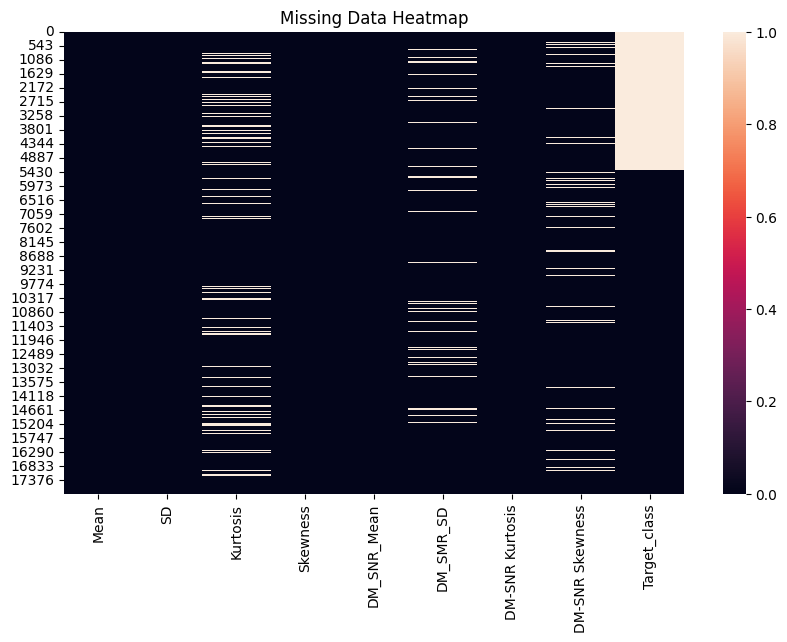

In [21]:
# Heatmap to visualize missing data

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull())
plt.title("Missing Data Heatmap")
plt.show()

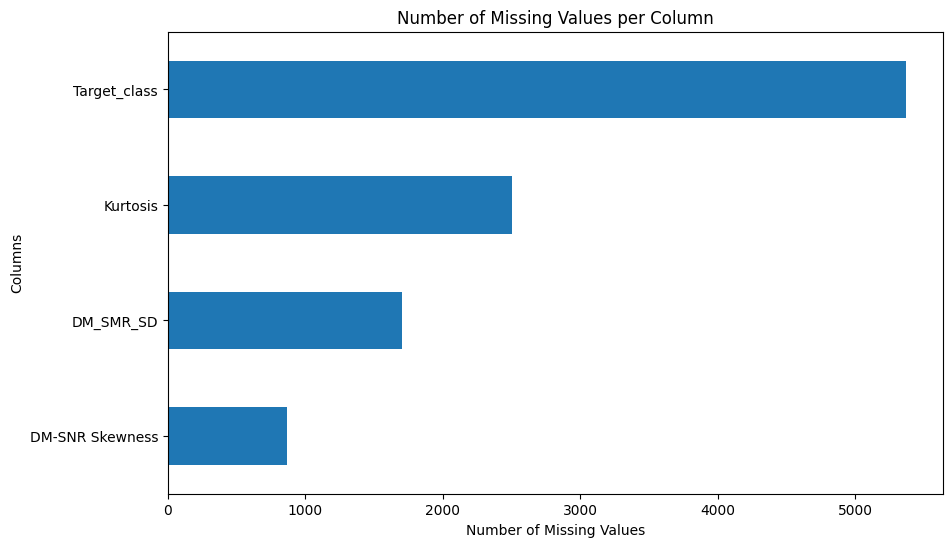

In [22]:
# Calculate the number of missing values per column

missing_values = df.isnull().sum()


# Filter out columns with no missing values

missing_values = missing_values[missing_values > 0]


# Plot the missing values as a bar chart

missing_values.sort_values().plot(kind='barh', figsize=(10, 6))
plt.title("Number of Missing Values per Column")
plt.xlabel("Number of Missing Values")
plt.ylabel("Columns")
plt.show()


In [23]:
# Handling missing values


# Drop rows where DM-SNR_Skewness is missing and modify the DataFrame in place

df.dropna(subset=['DM-SNR Skewness'], inplace=True)



# Verify that the missing values in the DM-SNR_Skewness column have been dropped

print(df.isnull().sum())

Mean                  0
SD                    0
Kurtosis           2362
Skewness              0
DM_SNR_Mean           0
DM_SMR_SD          1612
DM-SNR Kurtosis       0
DM-SNR Skewness       0
Target_class       5126
dtype: int64


In [24]:
skewness = df['DM_SMR_SD'].skew()
print(skewness)

1.8916798294765365


In [25]:
# The data is skewed (Positive skewness),so using the median might be more appropriate than mean to handling misssing values

In [26]:
df['DM_SMR_SD'] = df['DM_SMR_SD'].fillna(df['DM_SMR_SD'].mean())

In [27]:
# Replace inf values with NaN

df.replace([np.inf, -np.inf], np.nan, inplace=True)


,Mean,SD,Kurtosis,Skewness,DM_SNR_Mean,DM_SMR_SD,DM-SNR Kurtosis,DM-SNR Skewness,Target_class
0,116.906250,48.920605,0.186046,-0.129815,3.037625,17.737102,8.122621,78.813405,NaN
1,75.585938,34.386254,2.025498,8.652913,3.765050,21.897049,7.048189,55.878791,NaN
2,103.273438,46.996628,0.504295,0.821088,2.244983,15.622566,9.330498,105.134941,NaN
3,101.078125,48.587487,1.011427,1.151870,81.887960,81.464136,0.485105,-1.117904,NaN
4,113.226562,48.608804,0.291538,0.292120,6.291806,26.585056,4.540138,21.708268,NaN
...,...,...,...,...,...,...,...,...,...
17893,124.312500,53.179053,-0.012418,-0.556021,7.186455,29.308266,4.531382,21.725143,0.0
17894,115.617188,46.784600,0.218177,0.226757,6.140468,26.392505,5.732201,34.357283,0.0
17895,116.031250,43.213846,0.663456,0.433088,0.785117,11.628149,17.055215,312.204325,0.0
17896,135.664062,49.933749,-0.089940,-0.226726,3.859532,21.501505,7.398395,62.334018,0.0


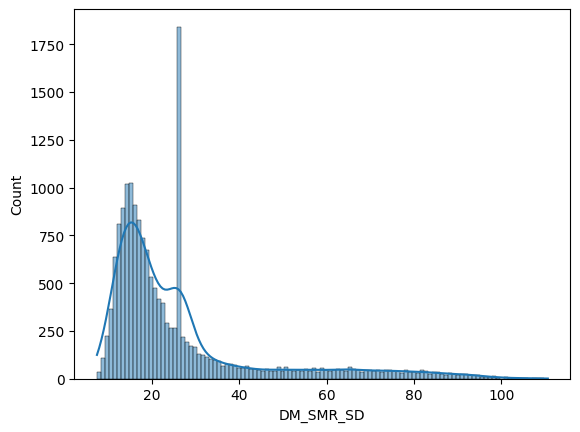

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['DM_SMR_SD'], kde=True)
plt.show()

In [29]:
#check Skewness before transformation 

print('before transformation:',df['DM_SMR_SD'].skew())



#Aplly Logarithmic Transformation

df['DM_SMR_SD']=np.log(df['DM_SMR_SD']+1)



#check Skewness after Transformation

print ('after transformation:',df['DM_SMR_SD'].skew())

before transformation: 1.9881002006020319
after transformation: 0.9334754239933493


In [30]:
#handling missing values in Target_class column using drop rows

df.dropna(subset=['Target_class'], inplace=True)

In [31]:
print(df.isnull().sum())

Mean                  0
SD                    0
Kurtosis           1644
Skewness              0
DM_SNR_Mean           0
DM_SMR_SD             0
DM-SNR Kurtosis       0
DM-SNR Skewness       0
Target_class          0
dtype: int64


In [32]:
#view summary statistics  in numerical variables 

round(des,2)

,Mean,SD,Kurtosis,Skewness,DM_SNR_Mean,DM_SMR_SD,DM-SNR Kurtosis,DM-SNR Skewness,Target_class
count,17898.00,17898.00,15396.00,17898.00,17898.00,16196.00,17898.00,17029.00,12528.00
mean,111.08,46.55,0.48,1.77,12.61,26.37,8.30,104.73,0.09
std,25.65,6.84,1.07,6.17,29.47,19.54,4.51,106.61,0.29
min,5.81,24.77,-1.88,-1.79,0.21,7.37,-3.14,-1.98,0.00
25%,100.93,42.38,0.03,-0.19,1.92,14.44,5.78,34.78,0.00
50%,115.08,46.95,0.22,0.20,2.80,18.46,8.43,82.77,0.00
75%,127.09,51.02,0.47,0.93,5.46,28.44,10.70,139.16,0.00
max,192.62,98.78,8.07,68.10,223.39,110.64,34.54,1191.00,1.00


In [33]:
# Visualize Outliers in Dataset

Text(0, 0.5, 'DM-SNR Skewness')

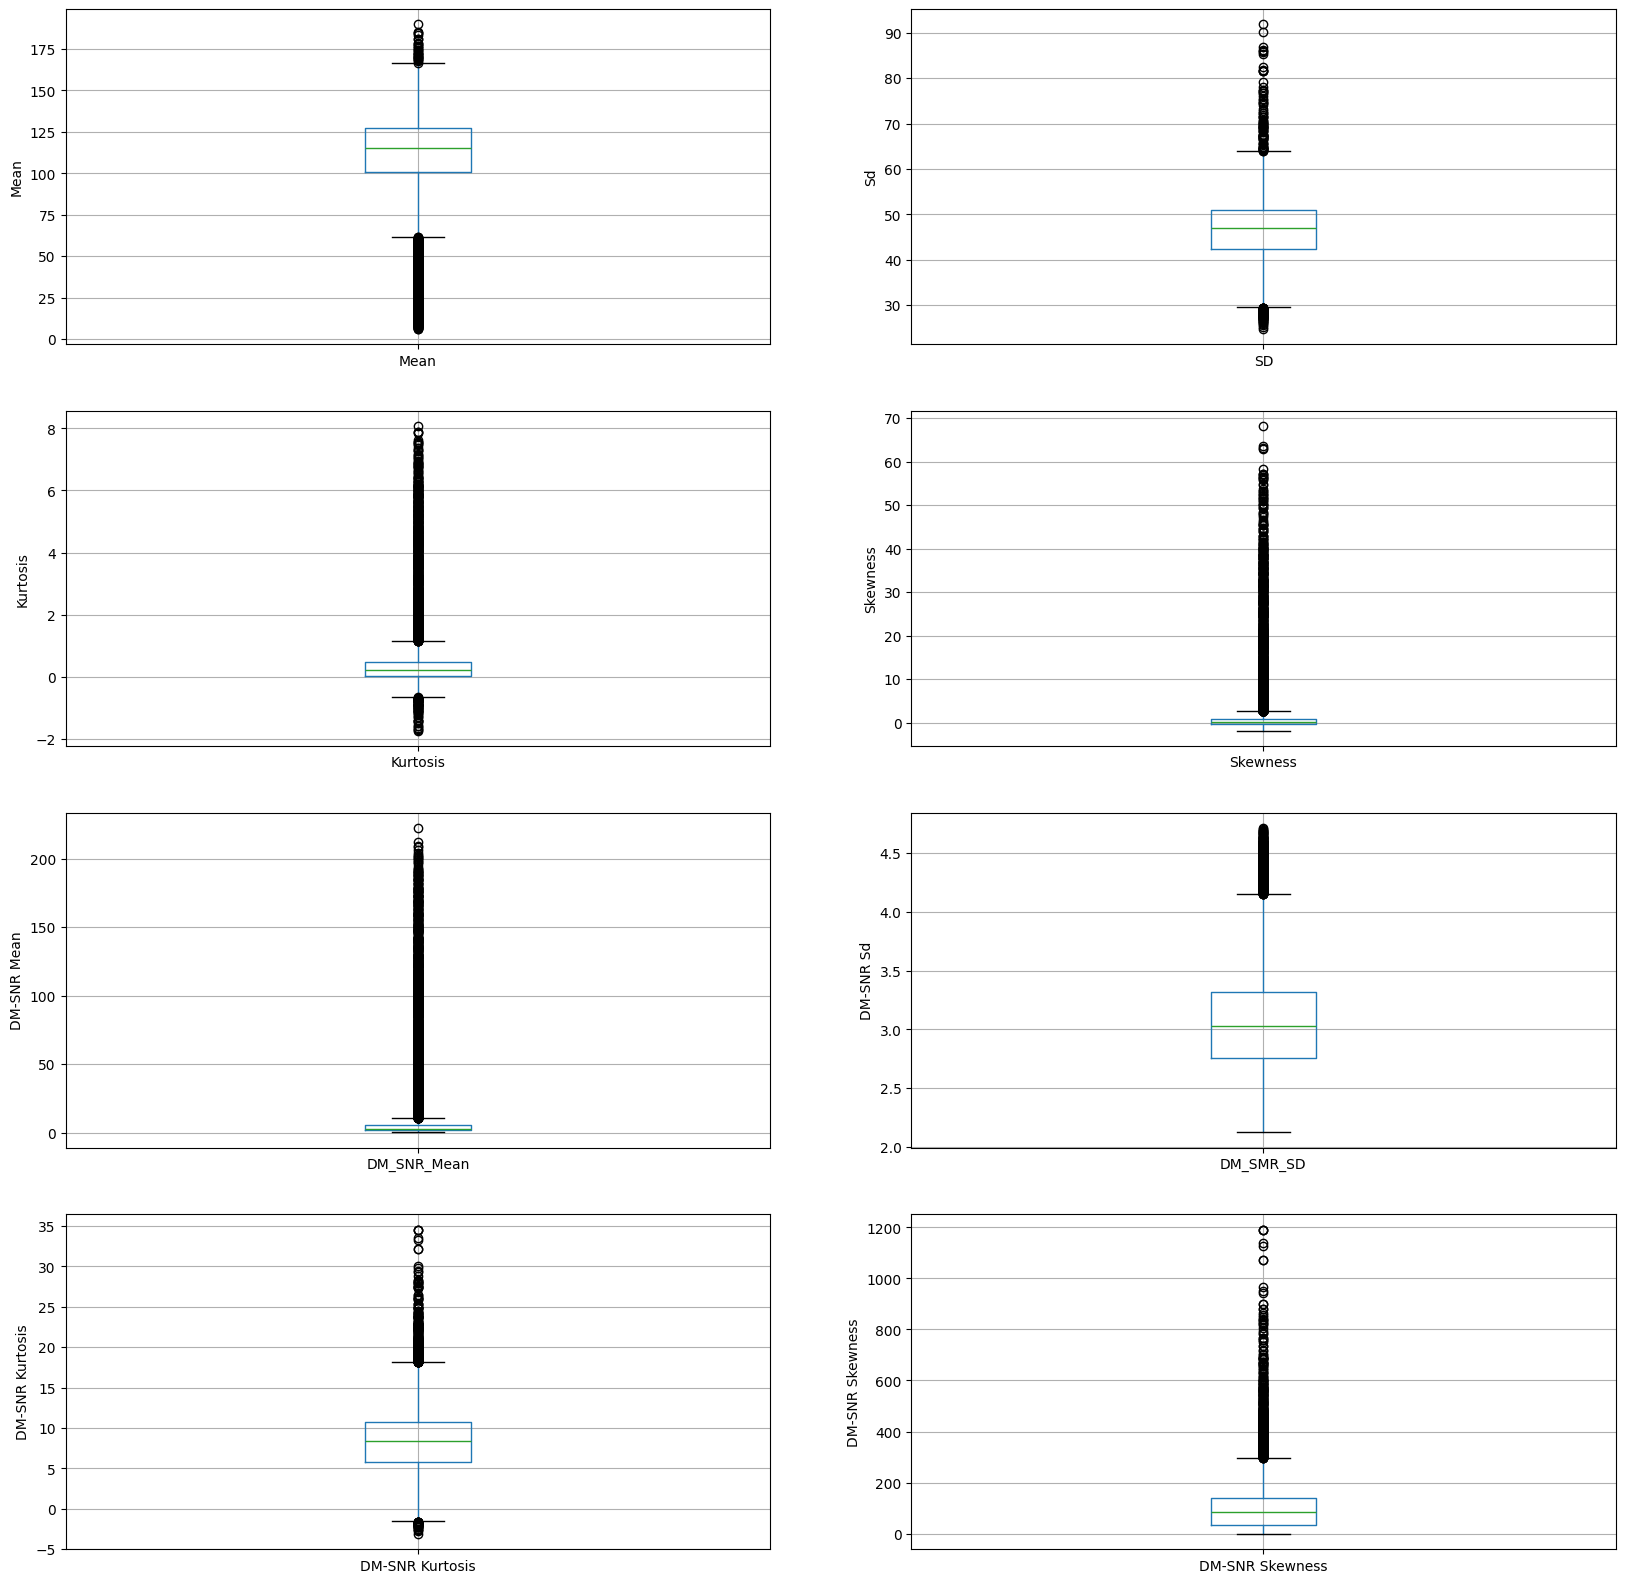

In [34]:
# draw boxplots to visualize outliers

plt.figure(figsize=(20,20))


plt.subplot(4, 2, 1)
fig = df.boxplot(column='Mean')
fig.set_title('')
fig.set_ylabel('Mean')


plt.subplot(4, 2, 2)
fig = df.boxplot(column='SD')
fig.set_title('')
fig.set_ylabel('Sd')



plt.subplot(4,2,3)
fig=df.boxplot(column='Kurtosis')
fig.set_title("")
fig.set_ylabel('Kurtosis')


plt.subplot(4, 2, 4)
fig = df.boxplot(column='Skewness')
fig.set_title('')
fig.set_ylabel('Skewness')


plt.subplot(4, 2, 5)
fig = df.boxplot(column='DM_SNR_Mean')
fig.set_title('')
fig.set_ylabel('DM-SNR Mean')


plt.subplot(4, 2, 6)
fig = df.boxplot(column='DM_SMR_SD')
fig.set_title('')
fig.set_ylabel('DM-SNR Sd')


plt.subplot(4, 2, 7)
fig = df.boxplot(column='DM-SNR Kurtosis')
fig.set_title('')
fig.set_ylabel('DM-SNR Kurtosis')


plt.subplot(4, 2, 8)
fig = df.boxplot(column='DM-SNR Skewness')
fig.set_title('')
fig.set_ylabel('DM-SNR Skewness')

Text(0, 0.5, 'Number of pulsar stars')

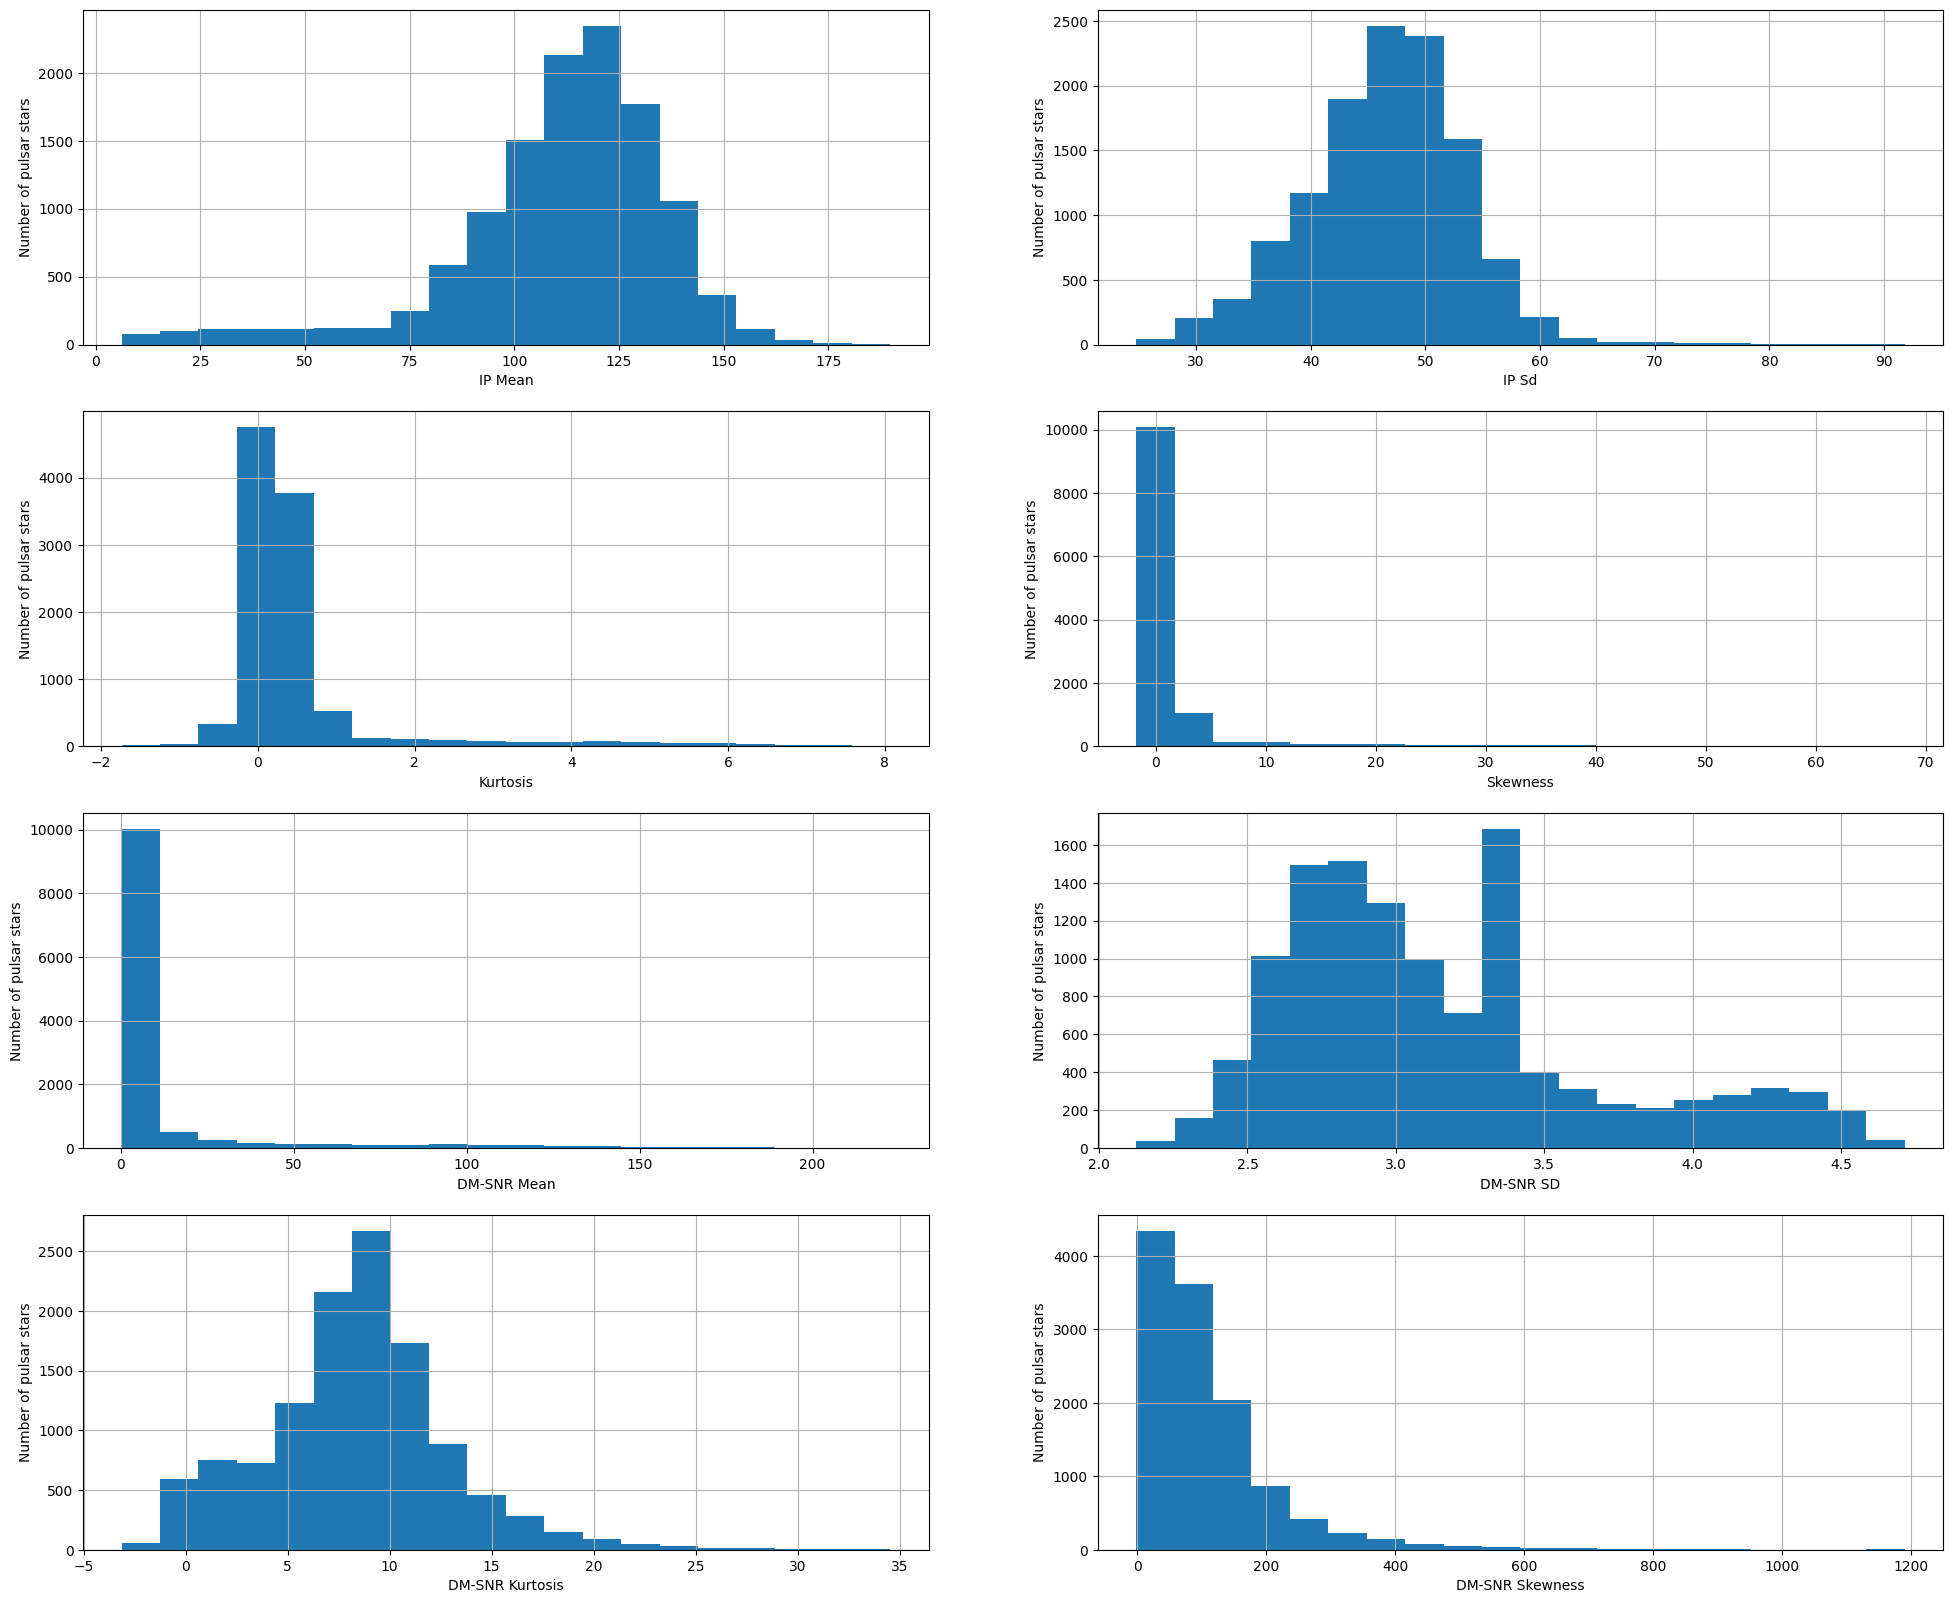

In [35]:
# plot histogram to check distribution


plt.figure(figsize=(24,20))


plt.subplot(4, 2, 1)
fig = df['Mean'].hist(bins=20)
fig.set_xlabel('IP Mean')
fig.set_ylabel('Number of pulsar stars')


plt.subplot(4, 2, 2)
fig = df['SD'].hist(bins=20)
fig.set_xlabel('IP Sd')
fig.set_ylabel('Number of pulsar stars')


plt.subplot(4, 2, 3)
fig = df['Kurtosis'].hist(bins=20)
fig.set_xlabel('Kurtosis')
fig.set_ylabel('Number of pulsar stars')



plt.subplot(4, 2, 4)
fig = df['Skewness'].hist(bins=20)
fig.set_xlabel('Skewness')
fig.set_ylabel('Number of pulsar stars')



plt.subplot(4, 2, 5)
fig = df['DM_SNR_Mean'].hist(bins=20)
fig.set_xlabel('DM-SNR Mean')
fig.set_ylabel('Number of pulsar stars')



plt.subplot(4, 2, 6)
fig = df['DM_SMR_SD'].hist(bins=20)
fig.set_xlabel('DM-SNR SD')
fig.set_ylabel('Number of pulsar stars')



plt.subplot(4, 2, 7)
fig = df['DM-SNR Kurtosis'].hist(bins=20)
fig.set_xlabel('DM-SNR Kurtosis')
fig.set_ylabel('Number of pulsar stars')


plt.subplot(4, 2, 8)
fig = df['DM-SNR Skewness'].hist(bins=20)
fig.set_xlabel('DM-SNR Skewness')
fig.set_ylabel('Number of pulsar stars')

In [36]:
# Handling Outlier Using SVM

In [37]:
# Declare feature vector and target variable

x=df.drop(['Target_class'],axis=1)
y = df['Target_class'] 

In [49]:
# Split Dataset 

from sklearn.model_selection  import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0) 

In [39]:
# check the shape of X_train and X_test

x_train.shape, x_test.shape

((9522, 8), (2381, 8))

In [40]:
# Feature scaling

In [62]:
# using standardscaler

from sklearn.preprocessing import StandardScaler

cols=x_train.columns

scaler=StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [63]:
# we made this step cuz after StanderdScaler step dataset convert from DATAFRAME into Array so we need back to Dataframe 

x_train = pd.DataFrame(x_train, columns=cols)
x_test = pd.DataFrame(x_test, columns=cols)

In [55]:
round(x_train.describe(),4)

,Mean,SD,Kurtosis,Skewness,DM_SNR_Mean,DM_SMR_SD,DM-SNR Kurtosis,DM-SNR Skewness
count,9522.0000,9522.0000,8194.0000,9522.0000,9522.0000,9522.0000,9522.0000,9522.0000
mean,111.3885,46.5720,0.4689,1.7394,12.7424,3.1501,8.3154,105.6499
std,25.5489,6.7386,1.0582,6.1464,29.6230,0.5302,4.5601,108.7779
min,6.1875,24.7720,-1.7380,-1.7919,0.2132,2.1247,-2.8124,-1.9770
25%,101.2188,42.4703,0.0231,-0.1903,1.9122,2.7578,5.7513,34.7461
50%,115.5156,46.9660,0.2198,0.1974,2.8089,3.0338,8.4279,83.0020
75%,127.3105,51.0509,0.4616,0.9069,5.4795,3.3217,10.7091,139.8800
max,189.7344,90.2506,8.0695,68.1016,209.3002,4.7153,34.5398,1191.0008


In [56]:
# Run SVM

In [65]:
print(x_train.isnull().sum())
print(y_train.isnull().sum())

Mean                  0
SD                    0
Kurtosis           1328
Skewness              0
DM_SNR_Mean           0
DM_SMR_SD             0
DM-SNR Kurtosis       0
DM-SNR Skewness       0
dtype: int64
0


In [66]:
x_train['Kurtosis'] = x_train['Kurtosis'].fillna(x_train['Kurtosis'].mean())

x_test['Kurtosis'] = x_test['Kurtosis'].fillna(x_test['Kurtosis'].mean())

In [67]:
print(x_train.isnull().sum())

Mean               0
SD                 0
Kurtosis           0
Skewness           0
DM_SNR_Mean        0
DM_SMR_SD          0
DM-SNR Kurtosis    0
DM-SNR Skewness    0
dtype: int64


In [68]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svc = SVC()

svc.fit(x_train, y_train)

y_pred = svc.predict(x_test)

print("Model Accuracy:", accuracy_score(y_test, y_pred))

Model Accuracy: 0.9739605207895842


In [69]:
# Visualization SVM

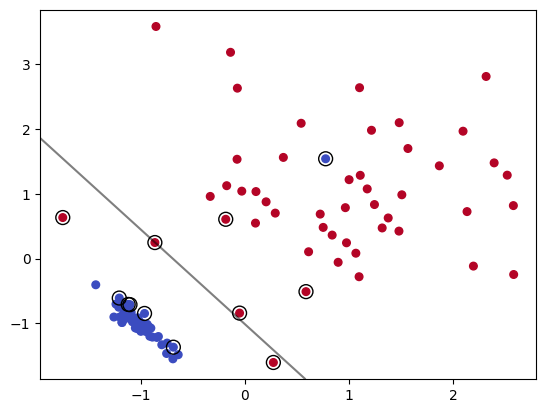

In [70]:
# Load a dataset

from sklearn import datasets
x, y = datasets.make_classification(n_features=2, n_redundant=0, n_informative=2,
                                    n_clusters_per_class=1, n_samples=100, random_state=6)

# Fit the SVM model

clf = SVC(kernel='linear', C=1.0)
clf.fit(x, y)


# Plot the data points

plt.scatter(x[:, 0], x[:, 1], c=y, cmap='coolwarm', s=30)


# Plot the decision boundary

ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 50),
                     np.linspace(ylim[0], ylim[1], 50))

Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)


# Decision boundary

ax.contour(xx, yy, Z, colors='k', levels=[0], alpha=0.5,
           linestyles=['-'])


# Support vectors

ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=100,
           linewidth=1, facecolors='none', edgecolors='k')

plt.show()

In [71]:
#instantiate  classifier with Linear kernal and C=1.0

# Support Vector Classification=SVC

clf = SVC(kernel='linear', C=1.0)


#fit classifier to training set

clf.fit(x_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [72]:
# Predictions

y_train_pred = clf.predict(x_train)
y_test_pred = clf.predict(x_test)


# Accuracy

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)


print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")

Training Accuracy: 0.98
Test Accuracy: 0.97


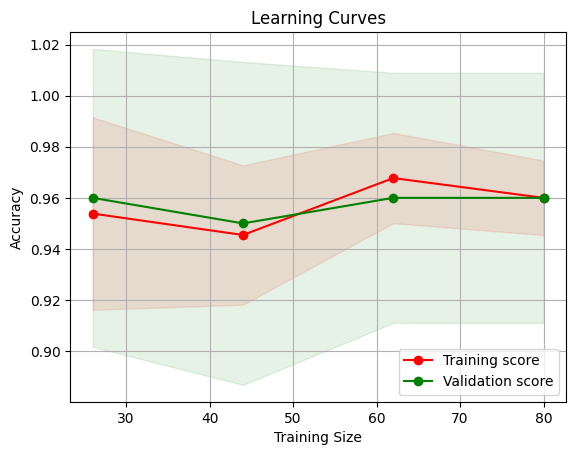

In [75]:
from sklearn.model_selection import learning_curve


# Learning curve

train_sizes, train_scores, validation_scores = learning_curve(
    clf, x, y, cv=5, scoring='accuracy', n_jobs=-1
)



# Mean and standard deviation of training scores

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)



# Mean and standard deviation of validation scores

validation_mean = np.mean(validation_scores, axis=1)
validation_std = np.std(validation_scores, axis=1)



# Plot

plt.figure()
plt.plot(train_sizes, train_mean, 'o-', color='r', label='Training score')
plt.plot(train_sizes, validation_mean, 'o-', color='g', label='Validation score')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, validation_mean - validation_std, validation_mean + validation_std, alpha=0.1, color='g')

plt.xlabel('Training Size')
plt.ylabel('Accuracy')
plt.title('Learning Curves')
plt.legend(loc='best')
plt.grid()
plt.show()

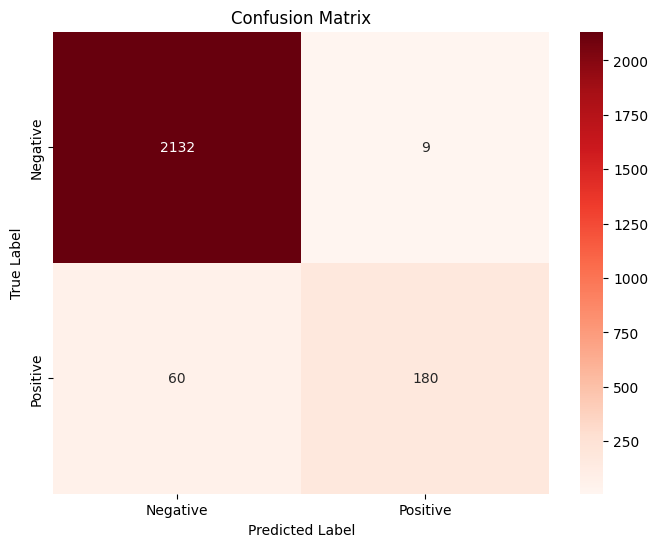

In [76]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix

# Assuming you have true labels y_test and predicted labels y_test_pred
cm = confusion_matrix(y_test, y_test_pred)

# Create a heatmap to visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [77]:
# Classification Metrix¶

# Classification report is another way to evaluate the classification model performance

In [78]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_test_pred))

              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98      2141
         1.0       0.95      0.75      0.84       240

    accuracy                           0.97      2381
   macro avg       0.96      0.87      0.91      2381
weighted avg       0.97      0.97      0.97      2381



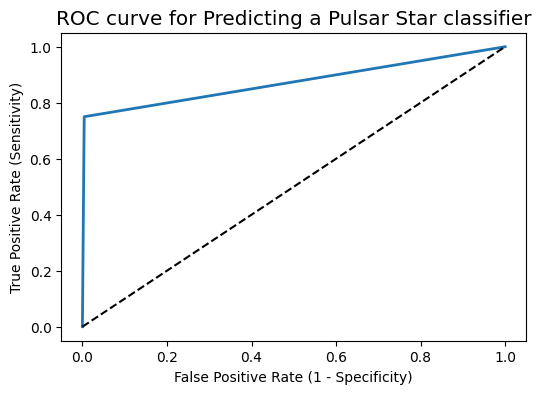

In [79]:
# plot ROC Curve

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_test_pred)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, linewidth=2)

plt.plot([0,1], [0,1],'k--' )

plt.rcParams['font.size'] = 12

plt.title('ROC curve for Predicting a Pulsar Star classifier')

plt.xlabel('False Positive Rate (1 - Specificity)')

plt.ylabel('True Positive Rate (Sensitivity)')

plt.show()